In [21]:
import numpy as np
import pandas as pd
import os
import pathlib
from joblib import Parallel, delayed
import contextlib
import joblib
from tqdm import tqdm
import warnings

from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_triangle, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max

from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.segmentation import expand_labels

from tifffile import imread
import tifffile

import napari

warnings.filterwarnings("ignore")

In [22]:
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """
    Enables parallel jobs to run and display of a tqdm progress bar.

    Parameters:
    -----------
    tqdm_object : tqdm
        The tqdm progress bar instance to be updated.
    """
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback
        tqdm_object.close()

In [23]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Convert an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [24]:
def pixel_size(tif_path):
    """
    Extract pixel size information from TIFF metadata.

    Parameters
    ----------
    tif_path : str
        Path to the TIFF file.

    Returns
    -------
    list
        List containing [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um].
    """
    with tifffile.TiffFile(tif_path) as tif:
        tif_tags = {}
        for tag in tif.pages[0].tags.values():
            name, value = tag.name, tag.value
            tif_tags[name] = value

        x_pixel_size_um = 1/((tif_tags["XResolution"])[0]/(tif_tags["XResolution"][1]))
        y_pixel_size_um = 1/((tif_tags["YResolution"])[0]/(tif_tags["YResolution"][1]))
        try:
            z_pixel_size_um = float(str(tif_tags["IJMetadata"]).split("nscales=")[1].split(",")[2].split("\\nunit")[0])
        except:
            z_pixel_size_um = (float(str(tif_tags["ImageDescription"]).split("spacing=")[1].split("loop")[0]))
       
    original_spacing = [x_pixel_size_um, y_pixel_size_um, z_pixel_size_um]
    return original_spacing

In [25]:
def convert(img, target_type_min, target_type_max, target_type):
    """
    Converts an image to a specified data type while scaling its intensity values.

    This function rescales the intensity values of an image from its original range 
    to a new target range specified by `target_type_min` and `target_type_max`, and 
    then converts it to the desired data type.

    This step is required as deconvolved images are not always scaled 0->255! 

    Parameters:
    -----------
    img : numpy.ndarray
        The input image array to be converted.
    target_type_min : int or float
        The minimum value of the target intensity range.
    target_type_max : int or float
        The maximum value of the target intensity range.
    target_type : numpy.dtype
        The desired data type of the output image (e.g., np.uint8, np.float32).

    Returns:
    --------
    new_img : numpy.ndarray
        The rescaled image with values mapped to the new intensity range and converted 
        to the specified data type.

    Notes:
    ------
    - This function performs a linear transformation to scale pixel values.
    - It ensures that the output values are properly mapped between `target_type_min` and 
      `target_type_max`.
    """
    imin = img.min()
    imax = img.max()

    a = (target_type_max - target_type_min) / (imax - imin)
    b = target_type_max - a * imax
    new_img = (a * img + b).astype(target_type)
    return new_img

In [26]:
def add_image_details(df, filename, flag):
    """
    Add experimental details extracted from the filename to a dataframe.

    This function parses the filename to infer experimental details such as 
    well number, imaging day, mechanical stiffness condition, and treatment type.
    The extracted details are appended as new columns to the dataframe.

    Parameters:
    -----------
    df : pandas.DataFrame
        The dataframe to which image metadata will be added.
    filename : str
        The filename of the image, used to extract experimental details.
    flag : str
        A flag indicating any segmentation issues detected during processing.

    Returns:
    --------
    df : pandas.DataFrame
        The updated dataframe with the following added columns:
        - 'filename': The original filename.
        - 'flag': Segmentation flag indicating potential issues.
        - 'well': The well number (1 or 2) inferred from the filename.
        - 'day': The experimental time point (0, 1, 3, or 7 days).
        - 'condition': The mechanical stiffness condition ('soft', 'stiff', or 'blank').
        - 'treatment': The treatment applied ('blebbistatin', 'ROCKi', 'batimastat', 'ABT737', or 'none').
        - 'image_type': A combined descriptor of the condition and day (e.g., 'soft, d3').
    """
    df["filename"] = filename
    df["flag"] = flag
    
    # Well number
    if "well1" in filename:
        df["well"] = 1
    else:
        df["well"] = 2
    
    # Day
    if "d0" in filename:
        df["day"] = 0
    elif "d1" in filename:
        df["day"] = 1
    elif "d3" in filename:
        df["day"] = 3
    else:
        df["day"] = 7
    
    # Stiffness
    if 'soft' in filename:
        df["condition"] = 'soft'
    elif 'stiff' in filename:
        df["condition"] = 'stiff'
    else:
        df["condition"] = 'blank'
    
    # Treatment
    if "bleb" in filename.lower():
        df["treatment"] = "blebbistatin"
    elif "rock" in filename.lower():
        df["treatment"] = "ROCKi"
    elif ("batimastat" in filename.lower()) or "mmpi" in filename.lower():
        df["treatment"] = "batimastat"
    elif "abt" in filename.lower():
        df["treatment"] = "ABT737"
    else:
        df["treatment"] = "none"
    
    df['image_type'] = df["condition"].astype(str) + ", d" + df["day"].astype(str)
    return df

In [27]:
def clean_and_watershed(image, acinus_labelled_image, new_pixel_size, separation_in_um=4, radius_threshold_um=2):
    """
    Clean binary mask and perform watershed segmentation to separate individual nuclei.

    Parameters
    ----------
    image : numpy.ndarray
        Binary or intensity image to segment.
    acinus_labelled_image : numpy.ndarray
        Labeled image defining acinus boundaries.
    new_pixel_size : float
        Pixel size in micrometers after rescaling.
    separation_in_um : float, optional
        Minimum distance in micrometers between detected nuclei centers (default: 4).
    radius_threshold_um : float, optional
        Minimum nuclear radius in micrometers for filtering (default: 2).

    Returns
    -------
    watershed_output : numpy.ndarray
        Labeled image with segmented and filtered nuclei.
    """
    cleaned_mask = image * acinus_labelled_image
    cleaned_mask = gaussian(cleaned_mask, 0.8)
    thresh = threshold_otsu(cleaned_mask)
    cleaned_mask = cleaned_mask > thresh
    cleaned_mask = remove_small_objects(cleaned_mask, min_size=1000)
    cleaned_mask = remove_small_holes(cleaned_mask, area_threshold=500)
    cleaned_mask = opening(cleaned_mask, ball(5))
    
    # Watershed nuclei
    distances = ndi.distance_transform_edt(erosion(cleaned_mask, ball(3)))
    nuclear_size_in_pixels = separation_in_um / new_pixel_size
    coordinates = peak_local_max(distances, min_distance=int(nuclear_size_in_pixels))
    marker_locations = coordinates.data
    markers = np.zeros(cleaned_mask.shape, dtype=np.uint32)
    marker_indices = tuple(np.round(marker_locations).astype(int).T)
    markers[marker_indices] = np.arange(len(marker_locations)) + 1
    markers_big = dilation(markers, ball(2))
    segmented = watershed(-distances, markers_big, mask=cleaned_mask)
    segmented = clear_border(segmented)
    
    # Filter out small nuclei
    table = regionprops_table(segmented, properties=('label', 'area'))
    volume_threshold = (4/3) * np.pi * (radius_threshold_um / new_pixel_size)**3
    condition = (table['area'] >= volume_threshold)
    input_labels = table['label']
    output_labels = input_labels * condition
    watershed_output = util.map_array(segmented, input_labels, output_labels)

    return watershed_output

In [48]:
def segment_and_quantify(i, image_paths,  DAPI_channel=0, actin_channel = 1, to_plot=False, shell_width_um = 5, inner_shell_offset_um = 10): 
    image = convert(imread(image_paths[i]), 0, 255, np.uint8)
    filename = str((os.path.basename(image_paths[i]))).lower()
    print(filename)
    try:
        # Scale the images
        acinus_image = image[:, DAPI_channel, :, :] + image[:, actin_channel, :, :]
        original_spacing = pixel_size(image_paths[i])
        scale_change = original_spacing[2] / original_spacing[0]
        new_pixel_size = 4 * original_spacing[0]
        acinus_rescaled = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=acinus_image, anti_aliasing=False)
        actin_rescaled = rescale(scale=(0.25*scale_change, 0.25, 0.25), image=image[:, actin_channel, :, :], anti_aliasing=False)
      
        # Clip and pre-process the acinus image to identify boundaries
        clipped = (acinus_rescaled).clip(min=np.quantile(acinus_rescaled, 0.05), max=np.quantile(acinus_rescaled, 0.85))
        acinus_smoothed = gaussian(clipped, sigma=10)
        thresh = threshold_otsu(acinus_smoothed)
        binary = acinus_smoothed > thresh
        binary = remove_small_holes(binary, area_threshold=100000)
        binary = remove_small_objects(binary, min_size=10000)
        binary = erosion(binary, ball(3))
        labelled_image = label(binary)
        table = regionprops_table(labelled_image, properties=('label', 'area'))
        condition = (table['area'] >= table['area'].max())
        # Filter the labels so we only keep the largest one
        input_labels = table['label']
        output_labels = input_labels * condition
        acinus_label = util.map_array(labelled_image, input_labels, output_labels)
        acinus_vol_in_um = [(region.area) * (new_pixel_size**3) for region in regionprops(acinus_label)][0]
        acinus_roundness = [(region.inertia_tensor_eigvals[2] / region.inertia_tensor_eigvals[0]) for region in regionprops(acinus_label)][0]
#############################################

        distance = (distance_transform_edt(acinus_label>0))
        
        # Quantify actin in two acinus-edge shells (all distances in um)

        shell_width_px = shell_width_um / new_pixel_size
        inner_shell_start_px = shell_width_px + (inner_shell_offset_um / new_pixel_size)
        inner_shell_end_px = inner_shell_start_px + shell_width_px

        acinus_mask = acinus_label > 0
        edge_shell_mask = acinus_mask & (distance > 0) & (distance <= shell_width_px)
        inner_shell_mask = acinus_mask & (distance > inner_shell_start_px) & (distance <= inner_shell_end_px)

        edge_shell_actin_total = actin_rescaled[edge_shell_mask].sum()
        inner_shell_actin_total = actin_rescaled[inner_shell_mask].sum()
        edge_shell_volume_um3 = edge_shell_mask.sum() * (new_pixel_size**3)
        inner_shell_volume_um3 = inner_shell_mask.sum() * (new_pixel_size**3)
        edge_shell_actin_median = np.median(actin_rescaled[edge_shell_mask]) if edge_shell_mask.sum() > 0 else np.nan
        inner_shell_actin_median = np.median(actin_rescaled[inner_shell_mask]) if inner_shell_mask.sum() > 0 else np.nan

        if not np.isnan(inner_shell_actin_median) and inner_shell_actin_median > 0:
            actin_shell_ratio_edge_to_inner = edge_shell_actin_median / inner_shell_actin_median
        else:
            actin_shell_ratio_edge_to_inner = np.nan
        all_cell_info_dict = {
            "filename": filename,
            "acinus_volume_um3": acinus_vol_in_um,
            "acinus_roundness": acinus_roundness,
            "actin_edge_shell_total": edge_shell_actin_total,
            "actin_inner_shell_total": inner_shell_actin_total,
            "actin_shell_ratio_edge_to_inner": actin_shell_ratio_edge_to_inner,
            "actin_edge_ring_median": edge_shell_actin_median,
            "actin_inner_ring_median": inner_shell_actin_median,
            "actin_edge_shell_volume_um3": edge_shell_volume_um3,
            "actin_inner_shell_volume_um3": inner_shell_volume_um3
        }
        all_cell_info = pd.DataFrame([all_cell_info_dict])
        all_cell_info = add_image_details(all_cell_info, filename, flag="OK")

#########################################################################

        if to_plot:
            inner_shell_start_um = shell_width_um + inner_shell_offset_um
            inner_shell_end_um = inner_shell_start_um + shell_width_um
            edge_shell_label = f'Edge Shell (0-{shell_width_um:g} um)'
            inner_shell_label = f'Inner Shell ({inner_shell_start_um:g}-{inner_shell_end_um:g} um)'
            viewer = napari.Viewer()
            viewer.add_labels(edge_shell_mask.astype(np.uint8), name=edge_shell_label)
            viewer.add_labels(inner_shell_mask.astype(np.uint8), name=inner_shell_label)
            viewer.add_labels(acinus_label, name='Acinus Image')
            viewer.add_image(actin_rescaled, name='Rescaled Actin Channel')
            napari.run()
    
    except Exception as e:
        print(f"Error processing {filename}: {str(e)}")
        all_cell_info = pd.DataFrame(columns=["label", "centroid-0", "centroid-1", "centroid-2", "corresponding_distance_matrix", "volume_um"], 
                               data=[["Fail", "Fail", "Fail", "Fail", "Fail", "Fail"]])
        all_cell_info["filename"] = filename
        all_cell_info["flag"] = "FAILED"
    
    return all_cell_info

## Single Image Analysis

Test the analysis pipeline on a single image to verify segmentation quality and parameters.

In [49]:
# Define paths to image directories
root = r"E:\Fabianna_N2_Images\integrin_analysis"
image_root = root + "\\tif"

# Get all image paths
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))

In [62]:
# Process a single image for testing
i = 19
all_cell_info = segment_and_quantify(i, image_paths, to_plot=True)

d7_stiff_12g10_c3010_cmle.tif


In [31]:
all_cell_info.head()

,filename,acinus_volume_um3,acinus_roundness,actin_edge_shell_total,actin_inner_shell_total,actin_shell_ratio_edge_to_inner,actin_edge_shell_mean,actin_inner_shell_mean,actin_edge_shell_volume_um3,actin_inner_shell_volume_um3,flag,well,day,condition,treatment,image_type
0,d7_stiff_12g10_c3010_cmle.tif,464739.392776,0.780558,161.370996,8251.378323,0.019557,0.000155,0.01436,81226.044457,44704.320171,OK,2,7,stiff,none,"stiff, d7"


## Batch Processing

Process all images in parallel to generate the complete dataset.

In [51]:
root = r"E:\Fabianna_N2_Images\integrin_analysis"
image_root = root + "\\tif"
image_paths = list(pathlib.Path(image_root).glob("**/*.tif"))

In [52]:
for shell_width_um in [2,3,5]:
    for inner_shell_offset_um in [5,10,15]:
        # Process all images in parallel
        with tqdm_joblib(tqdm(desc="Image Analysis", total=len(image_paths))) as progress_bar:
            all_cell_info = Parallel(n_jobs=4)(
                delayed(segment_and_quantify)(i, image_paths,  DAPI_channel=0, actin_channel = 1, to_plot=False, shell_width_um = shell_width_um, inner_shell_offset_um = inner_shell_offset_um)
                for i in range(len(image_paths))
            )

        # Combine results into a single DataFrame
        results_df = pd.concat(all_cell_info, ignore_index=True)
        results_df.to_csv(f"fabianna_integrin_upregulation_{shell_width_um}um_inner_{inner_shell_offset_um}um.csv")
        print(f"\nAnalysis complete! Completed for shell width {shell_width_um}um and inner shell offset {inner_shell_offset_um}um.")


Image Analysis: 100%|██████████| 20/20 [02:43<00:00,  8.18s/it]



Analysis complete! Completed for shell width 2um and inner shell offset 5um.


Image Analysis: 100%|██████████| 20/20 [02:30<00:00,  7.52s/it]



Analysis complete! Completed for shell width 2um and inner shell offset 10um.


Image Analysis: 100%|██████████| 20/20 [01:58<00:00,  5.90s/it]


...


Analysis complete! Completed for shell width 5um and inner shell offset 5um.


Image Analysis: 100%|██████████| 20/20 [02:14<00:00,  6.73s/it]



Analysis complete! Completed for shell width 5um and inner shell offset 10um.


Image Analysis: 100%|██████████| 20/20 [02:12<00:00,  6.61s/it]


Analysis complete! Completed for shell width 5um and inner shell offset 15um.


In [54]:
results = pd.read_csv(f"fabianna_integrin_upregulation_{5}um_inner_{10}um.csv")
results
# test = results.drop_duplicates(subset=['filename'], inplace=False)
# test

,Unnamed: 0,filename,acinus_volume_um3,acinus_roundness,actin_edge_shell_total,actin_inner_shell_total,actin_shell_ratio_edge_to_inner,actin_edge_ring_median,actin_inner_ring_median,actin_edge_shell_volume_um3,actin_inner_shell_volume_um3,flag,well,day,condition,treatment,image_type
0,0,d7_soft_12g10_c3001_cmle.tif,166784.263297,0.728790,27955.458514,923.229065,0.868900,0.008519,0.009804,82887.079856,2974.505039,OK,2,7,soft,none,"soft, d7"
1,1,d7_soft_12g10_c3002_cmle.tif,170246.460211,0.841869,43366.568565,10597.734792,1.020457,0.022425,0.021975,64744.232567,17930.316365,OK,2,7,soft,none,"soft, d7"
2,2,d7_soft_12g10_c3003_cmle.tif,151240.981616,0.789187,37626.855696,9490.501363,0.829755,0.016294,0.019637,60422.882216,14814.583953,OK,2,7,soft,none,"soft, d7"
3,3,d7_soft_12g10_c3004_cmle.tif,141402.413949,0.877650,37749.451068,0.000000,NaN,0.011952,NaN,83424.466728,0.000000,OK,2,7,soft,none,"soft, d7"
4,4,d7_soft_12g10_c3005_cmle.tif,164930.143605,0.765038,47498.870690,8757.490909,0.753033,0.018080,0.024010,70103.823922,11669.115992,OK,2,7,soft,none,"soft, d7"
5,5,d7_soft_12g10_c3006_cmle.tif,185061.254040,0.791915,29048.469090,7229.525011,0.664031,0.014108,0.021246,77082.880515,14594.562363,OK,2,7,soft,none,"soft, d7"
6,6,d7_soft_12g10_c3007_cmle.tif,184030.874391,0.713256,39897.022941,706.804902,0.500000,0.014902,0.029804,94036.622089,1072.177335,OK,2,7,soft,none,"soft, d7"
7,7,d7_soft_12g10_c3008_cmle.tif,73413.901386,0.901992,38686.297864,3013.097512,2.273325,0.019608,0.008625,35293.820270,3748.829732,OK,2,7,soft,none,"soft, d7"
8,8,d7_soft_12g10_c3009_cmle.tif,162113.712647,0.753601,36836.395087,1969.473361,0.616162,0.012861,0.020873,80299.460854,3561.277498,OK,2,7,soft,none,"soft, d7"
9,9,d7_soft_12g10_c3010_cmle.tif,224398.723012,0.853051,48854.621705,11579.249578,0.594427,0.016679,0.028059,92192.912662,15400.523667,OK,2,7,soft,none,"soft, d7"


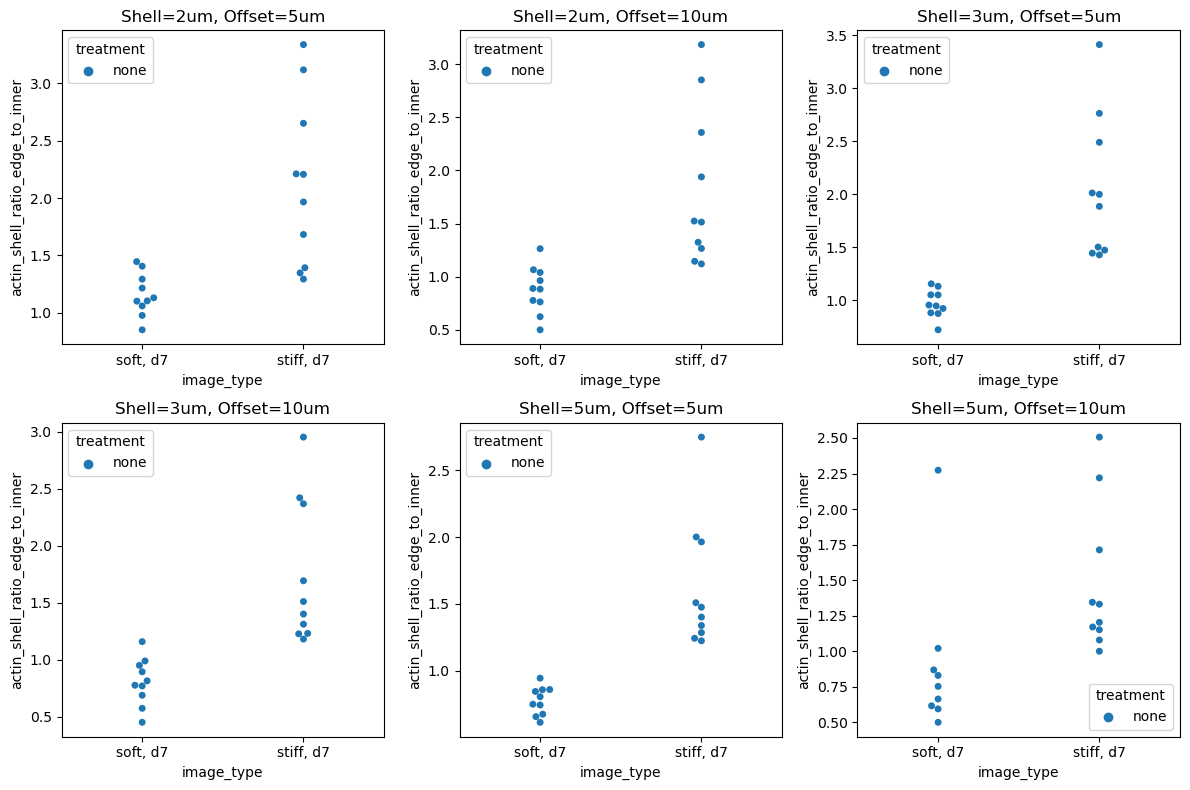

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(12, 8), ncols = 3, nrows = 2)
param_pairs = [(shell_width_um, inner_shell_offset_um) for shell_width_um in [2, 3, 5] for inner_shell_offset_um in [5, 10]]
for axis, (shell_width_um, inner_shell_offset_um) in zip(ax.flat, param_pairs):
    results = pd.read_csv(f"fabianna_integrin_upregulation_{shell_width_um}um_inner_{inner_shell_offset_um}um.csv")
    sns.swarmplot(data=results, x="image_type", y="actin_shell_ratio_edge_to_inner", hue="treatment", ax=axis)
    axis.set_title(f"Shell={shell_width_um}um, Offset={inner_shell_offset_um}um")
plt.tight_layout()
plt.savefig("fabianna_integrin_trafficking.png", dpi=300)
plt.savefig("fabianna_integrin_trafficking.pdf")